<h1 align="center"> Initial Plots </h1>

<br>
<i> Import necessary libraries: <i>

In [1]:
import sys
sys.path.append("..")

import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis 
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import math
from matplotlib.patches import Ellipse
import time
import random
from sklearn.preprocessing import StandardScaler
np.random.seed(2)

import os
from sklearn.model_selection import train_test_split
from scipy.stats import spearmanr

from src.optimise import capitalize_j, format_case_id

import umap
import seaborn as sns

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Matching Samples for Analysis

In [2]:
# Step 1: Load RNA-Seq data
df_rna = pd.read_csv("/home/kryan24/MRes_Ultrasound/data/rna_counts/RNA_counts_141024.csv", header=None, low_memory=False)
df_rna_transposed = df_rna.transpose()
new_header = df_rna_transposed.iloc[1]
df_rna_transposed = df_rna_transposed[2:]
df_rna_transposed.columns = new_header
df_rna_transposed.rename(columns=lambda x: x.strip(), inplace=True) # Trim whitespaces

# Step 3: Filter RNA data for 'ENSG' columns
rna_cols = df_rna_transposed.filter(like='ENSG')

# Step 4: Load and merge image data
df_images = pd.read_excel("/home/kryan24/MRes_Ultrasound/data/metadata/RNA_Sample_Linking2.xlsx")
df_images.rename(columns=lambda x: x.strip(), inplace=True) # Trim whitespaces
df_images['Sample ID'] = df_images['Sample ID'].str.replace(' ', '_')
df_images["SURGICAL"] = df_images["SURGICAL"].str.strip() # Remove whitespaces from SURGICAL

df_merged = pd.merge(df_images, df_rna_transposed, left_on="Sample ID", right_on="Geneid")

# Step 5: Correct data quality issues
df_merged["Extraction site"] = df_merged["Extraction site"].str.strip()
df_merged["Extraction site"] = df_merged["Extraction site"].str.lower()

# Step 6: Read the CSV file into a DataFrame 
df_radiomics = pd.read_csv("/home/kryan24/MRes_Ultrasound/data/metadata/radiomics_clinical_Barcroft_12_01_23.csv", low_memory=False)
# Remove first 2 columns
df_radiomics.drop(df_radiomics.columns[[0, 1]], axis=1, inplace=True)

# Filter columns
df_radiomics = df_radiomics.drop(df_radiomics.iloc[:, 3907:3950], axis=1)
df_radiomics["MAHCINE_CORECCTED"] = df_radiomics["MAHCINE_CORECCTED"].str.strip() # Remove whitespaces from MAHCINE_CORECCTED

# Step 7: Match radiomics data to metadata and filter DataFrame
df_radiomics_meta = df_merged[["Extraction site", "SURGICAL", "CASE ID", "CASE ID2"]]

# Step 8: Merge DataFrames
df_merged2 = pd.merge(df_radiomics_meta, df_radiomics, left_on="CASE ID", right_on="ID")

# Step 9: Correct data quality issues
df_merged2 = df_merged2.drop(["ID"], axis=1)

# Step 10: Keep the same samples for RNA as radiomics data
case_id_list = df_merged2["CASE ID"].tolist()
mask = df_merged["CASE ID"].isin(case_id_list)
df_merged = df_merged[mask]

In [3]:
# Check length of both sample dataframes
print("Number of rows in RNA samples:", df_merged.shape[0])
print("Number of rows in radiomics samples:", df_merged2.shape[0])

Number of rows in RNA samples: 36
Number of rows in radiomics samples: 36


### Pair Images and RNA Data

In [4]:
# Filter radiomics data 
rad_cols = df_merged2.drop(["Extraction site", "SURGICAL", "CASE ID", "CASE ID2", "MAHCINE_CORECCTED"], axis=1)

In [5]:
# Step 1: Prepare image filenames and filter data
image_directory = "/home/kryan24/MRes_Ultrasound/CLIPRNA/images_matched"
image_filenames_rna = []
image_filenames_rad = []
rna_data_filtered = []
rad_data_filtered = []
surgical_rna = []
surgical_rad = []
sample_count_rna = 0 
sample_count_rad = 0 

In [6]:
for index, row in df_merged.iterrows():

    # Format and capitalize the CASE IDs
    case_id = capitalize_j(format_case_id(row['CASE ID']))
    case_id2 = capitalize_j(format_case_id(row['CASE ID2']))

    for file_name in os.listdir(image_directory):
            if file_name.endswith('.nii.gz') and 'seg' not in file_name:
                file_name_corrected = capitalize_j(file_name)  # Capitalize 'j' in the filename

                # Check if either case_id or case_id2 is a substring of the filename
                # Only check if the ID is non-empty
                if (case_id and case_id in file_name_corrected) or (case_id2 and case_id2 in file_name_corrected):
                    image_filenames_rna.append(file_name)
                    rna_data_filtered.append(
                        row[rna_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0)
                    )
                    surgical_rna.append(row["SURGICAL"])
                    sample_count_rna += 1
                    break  # Only use the first matching image for each row

print(f"Number of Samples: ", sample_count_rna)

Number of Samples:  29


In [7]:
for index, row in df_merged2.iterrows():

    # Format and capitalize the CASE IDs
    case_id = capitalize_j(format_case_id(row['CASE ID']))
    case_id2 = capitalize_j(format_case_id(row['CASE ID2']))

    for file_name in os.listdir(image_directory):
            if file_name.endswith('.nii.gz') and 'seg' not in file_name:
                file_name_corrected = capitalize_j(file_name)  # Capitalize 'j' in the filename

                # Check if either case_id or case_id2 is a substring of the filename
                # Only check if the ID is non-empty
                if (case_id and case_id in file_name_corrected) or (case_id2 and case_id2 in file_name_corrected):
                    image_filenames_rad.append(file_name)
                    rad_data_filtered.append(
                        row[rad_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0)
                    )
                    surgical_rad.append(row["SURGICAL"])
                    sample_count_rad += 1
                    break  # Only use the first matching image for each row

print(f"Number of Samples: ", sample_count_rad)

Number of Samples:  29


In [8]:
flag = (surgical_rna == surgical_rad)
print(f"Matching Diagnoses: ", flag)

flag2 = (image_filenames_rna == image_filenames_rna)
print(f"Matching Images: ", flag2)

Matching Diagnoses:  True
Matching Images:  True


## Train Data

### Train-test Split

In [9]:
# Convert to DataFrame
rad_data_filtered = pd.DataFrame(rad_data_filtered)
# Convert to DataFrame
rna_data_filtered = pd.DataFrame(rna_data_filtered)

In [10]:
# Step 1: Split into train and test sets
rad_train, rad_test, rna_train, rna_test, surg_train, surg_test, img_train, img_test = train_test_split(rad_data_filtered, rna_data_filtered, surgical_rad, image_filenames_rad, test_size=0.2, random_state=2)

In [11]:
# Convert back to DataFrame
rad_train = pd.DataFrame(rad_train, columns=rad_data_filtered.columns)
rad_test = pd.DataFrame(rad_test, columns=rad_data_filtered.columns)
# Convert back to DataFrame
rna_train = pd.DataFrame(rna_train, columns=rna_data_filtered.columns)
rna_test = pd.DataFrame(rna_test, columns=rna_data_filtered.columns)

In [12]:
print(f"Number of RNA samples: ", rna_train.shape[0])
print(f"Number of radiomics samples: ", rad_train.shape[0])
print(f"Number of image filenames: ", len(img_train))
print(f"Number of diagnoses: ", len(surg_train))
print(f"Image filenames: ", img_train)
print(f"Diagnoses: ", surg_train)

Number of RNA samples:  23
Number of radiomics samples:  23
Number of image filenames:  23
Number of diagnoses:  23
Image filenames:  ['24903_0011.nii.gz', '14984_0039.nii.gz', '14056_3.nii.gz', '25962_0006.nii.gz', '26604_0007.nii.gz', '26428_0020.nii.gz', '187867.nii.gz', '14654_3.nii.gz', '16439_0004.nii.gz', '14024_2.nii.gz', '25970_2.nii.gz', '25607_0005.nii.gz', '14023_3.nii.gz', '16106_0022.nii.gz', '26425_-3.nii.gz', '26417_1.nii.gz', '25827_0006.nii.gz', '18638_0037.nii.gz', 'J630_0008.nii.gz', '26379_5.nii.gz', '18853_0020.nii.gz', '24354_0019.nii.gz', '16134_0049.nii.gz']
Diagnoses:  ['M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'B-S', 'M-S', 'M-S', 'M-S', 'M-S', 'B-S', 'B-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S']


In [13]:
print(f"Number of RNA samples: ", rna_test.shape[0])
print(f"Number of radiomics samples: ", rad_test.shape[0])
print(f"Number of image filenames: ", len(img_test))
print(f"Number of diagnoses: ", len(surg_test))
print(f"Image filenames: ", img_test)
print(f"Diagnoses: ", surg_test)

Number of RNA samples:  6
Number of radiomics samples:  6
Number of image filenames:  6
Number of diagnoses:  6
Image filenames:  ['13291_0010.nii.gz', '12930_3.nii.gz', '18852_0009.nii.gz', '16208_1.nii.gz', '25961_2.nii.gz', '26424_0007.nii.gz']
Diagnoses:  ['M-S', 'B-S', 'B-S', 'B-S', 'M-S', 'M-S']


### Radiomics Tabular Data

In [14]:
# Scale radiomics sample counts
rad_scaler = StandardScaler()
rad_train_df = pd.DataFrame(rad_scaler.fit_transform(rad_train), columns=rad_data_filtered.columns)
rad_train_df.insert(0, "SURGICAL", surg_train)

In [15]:
rad_train_df

,SURGICAL,N.voxels,SNS_vol,SNS_area,SNS_s2v,SNS_sph,SNS_sph_dis,SNS_com_1,SNS_com_2,SNS_max3d,...,GLCM_sumVar_HHH_256gl,GLCM_sumEnt_HHH_256gl,GLCM_difVar_HHH_256gl,GLCM_difEnt_HHH_256gl,GLCM_AutoCorrel_HHH_256gl,GLCM_ClTend_HHH_256gl,GLCM_Homoge1_HHH_256gl,GLCM_IDMN_HHH_256gl,GLCM_IDN_HHH_256gl,GLCM_invVar_HHH_256gl
0,M-S,-0.300256,-0.300256,-0.290585,0.597678,-0.105510,-0.094246,-0.136137,-0.229996,-0.202961,...,-0.099689,-0.458526,0.391541,-0.393965,0.276943,-0.099689,1.140061,0.172859,0.577589,0.389640
1,M-S,0.708814,0.708814,0.736585,1.174269,-0.707359,0.814816,0.702319,-0.512319,0.530002,...,-0.767278,-0.340934,-0.555317,-0.244707,-0.545344,-0.767278,0.349374,0.630998,0.589885,0.487917
2,M-S,0.389183,0.389183,0.387646,-0.430245,-0.528508,0.505664,0.512884,-0.440065,0.297776,...,-0.664274,-0.260948,-0.957752,-0.544056,-1.938336,-0.664274,-0.129701,0.920321,0.795541,0.903431
3,M-S,0.804797,0.804797,0.794266,-1.011904,-0.728401,0.823329,0.862983,-0.528572,0.213413,...,-0.129329,0.237998,-0.025076,0.126134,0.566347,-0.129329,-0.405166,0.161605,0.122408,0.272718
4,M-S,-1.077737,-1.077737,-1.082357,-0.309010,0.693260,-1.015069,-0.975551,0.259959,-1.188107,...,-0.911763,-3.335527,-0.479147,-3.189218,0.584849,-0.911763,3.456858,0.791839,1.492986,-1.088405
5,M-S,-0.641473,-0.641473,-0.648713,0.138136,0.814252,-0.764388,-0.734809,0.710243,-0.009742,...,0.711398,0.687845,1.251147,0.903606,-0.344830,0.711398,-0.716272,-1.058690,-0.917550,-0.399998
6,M-S,1.830349,1.830349,1.815305,-1.205505,-1.141776,1.560108,1.599209,-0.692007,1.821759,...,-0.971624,-0.228353,-1.068968,-0.326319,1.535946,-0.971624,-0.354793,0.922945,0.623815,0.269649
7,M-S,-0.766506,-0.766506,-0.772586,-0.451748,0.554124,-0.752406,-0.709619,0.245511,-0.831604,...,-0.473823,-0.316588,-0.583241,-0.412936,-1.335967,-0.473823,0.419077,0.631495,0.635470,0.245509
8,B-S,0.231533,0.231533,0.221065,-0.992312,-0.416715,0.341899,0.390684,-0.386374,0.248791,...,-1.260083,-0.937788,-1.090119,-0.929800,0.228808,-1.260083,0.509548,1.149639,1.243921,1.998762
9,M-S,-0.642724,-0.642724,-0.639762,0.317509,0.231870,-0.492534,-0.502714,-0.028335,-0.714584,...,0.227803,0.378871,0.503079,0.357899,-1.443137,0.227803,-0.402971,-0.274350,-0.192197,0.349811


In [16]:
# Scale radiomics sample counts
rad_test_df = pd.DataFrame(rad_scaler.transform(rad_test), columns=rad_data_filtered.columns)
rad_test_df.insert(0, "SURGICAL", surg_test)

In [17]:
rad_test_df

,SURGICAL,N.voxels,SNS_vol,SNS_area,SNS_s2v,SNS_sph,SNS_sph_dis,SNS_com_1,SNS_com_2,SNS_max3d,...,GLCM_sumVar_HHH_256gl,GLCM_sumEnt_HHH_256gl,GLCM_difVar_HHH_256gl,GLCM_difEnt_HHH_256gl,GLCM_AutoCorrel_HHH_256gl,GLCM_ClTend_HHH_256gl,GLCM_Homoge1_HHH_256gl,GLCM_IDMN_HHH_256gl,GLCM_IDN_HHH_256gl,GLCM_invVar_HHH_256gl
0,M-S,-0.354384,-0.354384,-0.345940,0.540260,-0.007476,-0.185398,-0.220516,-0.160341,-0.206590,...,-0.222020,-0.282968,-0.083156,-0.340126,1.689428,-0.222020,0.191474,0.177335,0.413888,1.215397
1,B-S,0.289299,0.289299,0.301256,0.419084,-0.496781,0.456292,0.407018,-0.425741,-0.202961,...,-0.679000,-0.202192,-0.520269,-0.287718,-1.203773,-0.679000,-0.118794,0.644606,0.616620,0.982132
2,B-S,-0.929290,-0.929290,-0.937507,-0.667193,0.624517,-0.893797,-0.835826,0.245671,-0.970395,...,-1.117869,-0.994883,-1.154391,-0.977268,2.569243,-1.117869,1.413255,1.178403,1.200711,0.048004
3,B-S,-1.317145,-1.317145,-1.323921,-0.461087,1.030815,-1.343465,-1.286794,0.504152,-1.465690,...,1.381705,0.988686,1.141291,0.930430,-1.747516,1.381705,-0.802945,-1.094815,-1.008092,-0.636333
4,M-S,0.384722,0.384722,0.397021,0.396420,-0.550822,0.538642,0.488177,-0.450665,1.549619,...,-0.369855,0.037312,-0.257915,-0.040500,1.378243,-0.369855,-0.256747,0.405549,0.353259,0.493791
5,M-S,-1.572517,-1.572517,-1.564027,2.062520,1.384019,-1.653006,-1.713466,0.787626,1.037997,...,-2.179672,-3.712603,-2.348192,-3.897961,0.618939,-2.179672,2.509443,2.224327,3.039694,7.993056


In [18]:
rad_train_test_df = pd.concat([rad_train_df, rad_test_df], ignore_index=True)

In [19]:
rad_train_test_df

,SURGICAL,N.voxels,SNS_vol,SNS_area,SNS_s2v,SNS_sph,SNS_sph_dis,SNS_com_1,SNS_com_2,SNS_max3d,...,GLCM_sumVar_HHH_256gl,GLCM_sumEnt_HHH_256gl,GLCM_difVar_HHH_256gl,GLCM_difEnt_HHH_256gl,GLCM_AutoCorrel_HHH_256gl,GLCM_ClTend_HHH_256gl,GLCM_Homoge1_HHH_256gl,GLCM_IDMN_HHH_256gl,GLCM_IDN_HHH_256gl,GLCM_invVar_HHH_256gl
0,M-S,-0.300256,-0.300256,-0.290585,0.597678,-0.105510,-0.094246,-0.136137,-0.229996,-0.202961,...,-0.099689,-0.458526,0.391541,-0.393965,0.276943,-0.099689,1.140061,0.172859,0.577589,0.389640
1,M-S,0.708814,0.708814,0.736585,1.174269,-0.707359,0.814816,0.702319,-0.512319,0.530002,...,-0.767278,-0.340934,-0.555317,-0.244707,-0.545344,-0.767278,0.349374,0.630998,0.589885,0.487917
2,M-S,0.389183,0.389183,0.387646,-0.430245,-0.528508,0.505664,0.512884,-0.440065,0.297776,...,-0.664274,-0.260948,-0.957752,-0.544056,-1.938336,-0.664274,-0.129701,0.920321,0.795541,0.903431
3,M-S,0.804797,0.804797,0.794266,-1.011904,-0.728401,0.823329,0.862983,-0.528572,0.213413,...,-0.129329,0.237998,-0.025076,0.126134,0.566347,-0.129329,-0.405166,0.161605,0.122408,0.272718
4,M-S,-1.077737,-1.077737,-1.082357,-0.309010,0.693260,-1.015069,-0.975551,0.259959,-1.188107,...,-0.911763,-3.335527,-0.479147,-3.189218,0.584849,-0.911763,3.456858,0.791839,1.492986,-1.088405
5,M-S,-0.641473,-0.641473,-0.648713,0.138136,0.814252,-0.764388,-0.734809,0.710243,-0.009742,...,0.711398,0.687845,1.251147,0.903606,-0.344830,0.711398,-0.716272,-1.058690,-0.917550,-0.399998
6,M-S,1.830349,1.830349,1.815305,-1.205505,-1.141776,1.560108,1.599209,-0.692007,1.821759,...,-0.971624,-0.228353,-1.068968,-0.326319,1.535946,-0.971624,-0.354793,0.922945,0.623815,0.269649
7,M-S,-0.766506,-0.766506,-0.772586,-0.451748,0.554124,-0.752406,-0.709619,0.245511,-0.831604,...,-0.473823,-0.316588,-0.583241,-0.412936,-1.335967,-0.473823,0.419077,0.631495,0.635470,0.245509
8,B-S,0.231533,0.231533,0.221065,-0.992312,-0.416715,0.341899,0.390684,-0.386374,0.248791,...,-1.260083,-0.937788,-1.090119,-0.929800,0.228808,-1.260083,0.509548,1.149639,1.243921,1.998762
9,M-S,-0.642724,-0.642724,-0.639762,0.317509,0.231870,-0.492534,-0.502714,-0.028335,-0.714584,...,0.227803,0.378871,0.503079,0.357899,-1.443137,0.227803,-0.402971,-0.274350,-0.192197,0.349811


### Radiomics - Principal Component Analysis (2 Components)

#### All features

In [20]:
# Seperating out the features
rad_all = rad_train_test_df.drop(["SURGICAL"], axis=1)
# Seperating out the target
rad_class = rad_train_test_df[["SURGICAL"]]

In [21]:
def draw_umap_class(n_neighbors=15, min_dist=0.1, n_components=2, metric='euclidean', title='', num_features=""):

    rad_reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        metric=metric
    )

    rad_umap_results = rad_reducer.fit_transform(num_features)

    fig, ax = plt.subplots(figsize=(5, 6))
    plt.rcParams['axes.spines.left'] = True
    plt.rcParams['axes.spines.right'] = True
    plt.rcParams['axes.spines.top'] = True
    plt.rcParams['axes.spines.bottom'] = True

    targets = ["B-S", "M-S"]
    colours = ["#17BECF", "#9467BD"]

    sns.scatterplot(x=rad_umap_results[:,0], y=rad_umap_results[:,1], hue=rad_class.SURGICAL, palette=colours, hue_order=targets, alpha=0.7, s=95)

    ax.grid(which="major", color="#EEEEEE", linewidth=0.5)
    ax.set_xlabel("Dim1", fontsize=10, labelpad=15)
    ax.set_ylabel("Dim2", fontsize=10, labelpad=15)
    ax.set_title(title, fontsize = 15, pad=10)
    plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
    plt.show()

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


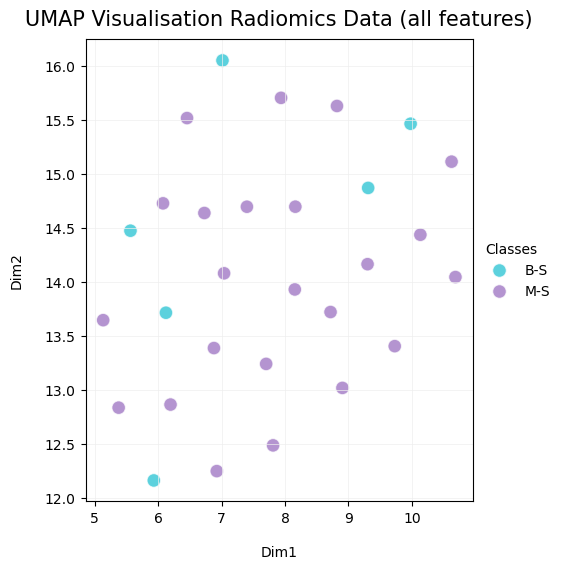

In [22]:
draw_umap_class(n_neighbors=50, min_dist=0.5, title="UMAP Visualisation Radiomics Data (all features)", num_features=rad_all)

#### Run LDA on the Original Dataset to Select Features

In [23]:
# Divide the dataset into features (X) and target variable (y)
X = rad_train_test_df.drop(["SURGICAL"], axis=1)
y = rad_train_test_df[["SURGICAL"]]

# Fit the LDA model
model = LinearDiscriminantAnalysis()
model.fit(X, y)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LinearDiscriminantAnalysis()

In [24]:
# Print coefficient table
coef_table = pd.DataFrame(list(X.columns)).copy()
coef_table.insert(len(coef_table.columns), "Coefficients", model.coef_.transpose())
coef_table

,0,Coefficients
0,N.voxels,0.005293
1,SNS_vol,0.005293
2,SNS_area,0.005147
3,SNS_s2v,-0.012559
4,SNS_sph,0.000375
...,...,...
3901,GLCM_ClTend_HHH_256gl,-0.001291
3902,GLCM_Homoge1_HHH_256gl,0.000041
3903,GLCM_IDMN_HHH_256gl,-0.000740
3904,GLCM_IDN_HHH_256gl,0.000773


In [25]:
# Add absoloute coefficients column
coef_table["Absolute Coefficients"] = coef_table["Coefficients"].abs()
coef_table

,0,Coefficients,Absolute Coefficients
0,N.voxels,0.005293,0.005293
1,SNS_vol,0.005293,0.005293
2,SNS_area,0.005147,0.005147
3,SNS_s2v,-0.012559,0.012559
4,SNS_sph,0.000375,0.000375
...,...,...,...
3901,GLCM_ClTend_HHH_256gl,-0.001291,0.001291
3902,GLCM_Homoge1_HHH_256gl,0.000041,0.000041
3903,GLCM_IDMN_HHH_256gl,-0.000740,0.000740
3904,GLCM_IDN_HHH_256gl,0.000773,0.000773


In [26]:
# Sort absolute coefficients 
coef_table = coef_table.sort_values(by="Absolute Coefficients", ascending=False)
coef_table

,0,Coefficients,Absolute Coefficients
3388,FD_max_HHL_128gl,-1.133704,1.133704
3821,FD_max_HHH_128gl,-1.133704,1.133704
3208,FD_max_HHL_16gl,-0.613610,0.613610
3641,FD_max_HHH_16gl,-0.613610,0.613610
2402,FD_max_HLL_32gl,-0.404986,0.404986
...,...,...,...
491,FD_min_LLL_4gl,0.000000,0.000000
3268,FD_max_HHL_32gl,0.000000,0.000000
1536,FD_max_LHL_32gl,0.000000,0.000000
1357,FD_min_LHL_4gl,0.000000,0.000000


In [27]:
# Store top 1000 features
top_1000_rad = coef_table[0].head(1000).to_list()

In [28]:
# Seperating out the features
rad_1000 = rad_train_test_df.drop(["SURGICAL"], axis=1)
# Only keep the top 1000 features
rad_1000 = rad_1000.loc[:, rad_1000.columns.isin(top_1000_rad)]
# Seperating out the target
rad_class = rad_train_test_df[["SURGICAL"]]

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


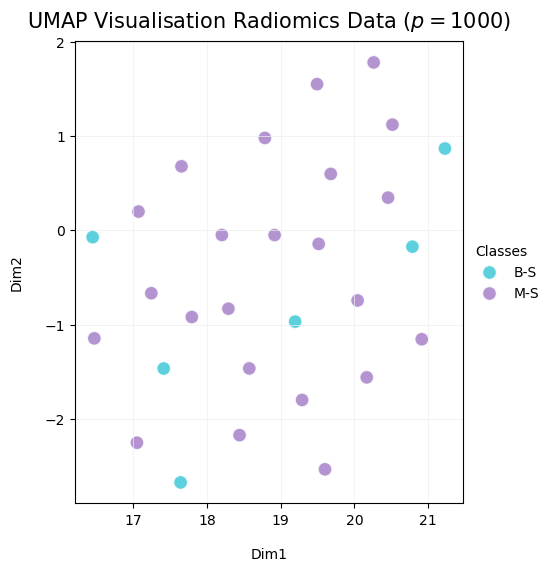

In [29]:
draw_umap_class(n_neighbors=50, min_dist=0.5, title="UMAP Visualisation Radiomics Data ($p=1000$)", num_features=rad_1000)

#### Spearman Rho Correlation Coefficient

In [30]:
# Seperating out the features
rad_all = rad_train_test_df.drop(["SURGICAL"], axis=1)
# Seperating out the target
rad_class_cat = pd.Categorical(rad_train_test_df["SURGICAL"].astype("category")).codes

In [32]:
thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

def spearman_thresh_function(features, target, thresholds):
    threshold_list = []
    num_features = []

    column_names = features.columns.tolist()

    for threshold in thresholds:
        threshold_list.append(threshold)
        count = 0
        for column in column_names:
            corr, pval = spearmanr(features[column], target)
            if (corr != 0.9):
                if (corr >= threshold and corr <= threshold+1):
                    count += 1
            else:
                if (corr >= threshold):
                    count += 1
        num_features.append(count)

    return threshold_list, num_features

In [33]:
rad_thresholds, rad_threshold_counts = spearman_thresh_function(rad_all, rad_class_cat, thresholds)

/tmp/ipykernel_66783/673404981.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(features[column], target)


In [34]:
threshold_df = pd.DataFrame(
    {
        "Threshold": map(str, rad_thresholds),
        "Feature Count": rad_threshold_counts
    }
)

threshold_df

,Threshold,Feature Count
0,0,2511
1,0.1,1280
2,0.2,444
3,0.3,140
4,0.4,14
5,0.5,0
6,0.6,0
7,0.7,0
8,0.8,0
9,0.9,0


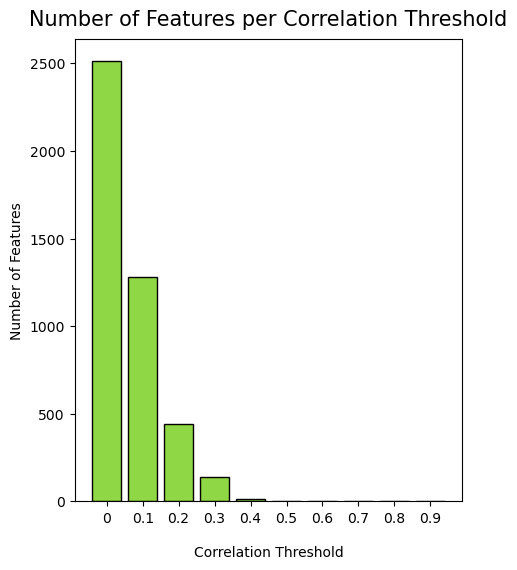

In [35]:
fig,ax = plt.subplots(figsize=(5, 6)) 
ax.bar(threshold_df["Threshold"], threshold_df["Feature Count"], color="#8FD744FF", edgecolor="black")
ax.set_title("Number of Features per Correlation Threshold", fontsize = 15, pad=10)
ax.set_xlabel("Correlation Threshold", fontsize=10, labelpad=15)
ax.set_ylabel("Number of Features", fontsize=10)
plt.show()

In [32]:
def spearman_df_function(features, target, threshold):
    feature_names = []
    feature_correlations = []
    
    column_names = features.columns.tolist()

    for column in column_names:
        corr, pval = spearmanr(features[column], target)
        if (corr >= threshold):
            feature_names.append(column)
            feature_correlations.append(corr)

    return feature_names, feature_correlations

In [33]:
rad_feature_names, rad_feature_correlations = spearman_df_function(rad_all, rad_class_cat, 0.4)

/tmp/ipykernel_66918/2827494689.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(features[column], target)


In [34]:
spearman_df = pd.DataFrame(
    {
        "Features": rad_feature_names,
        "Correlations": rad_feature_correlations
    }
)

spearman_df

,Features,Correlations
0,GLCM_Varian_8gl,0.417153
1,GLCM_ClProm_8gl,0.437502
2,GLCM_sumVar_8gl,0.406978
3,GLCM_ClTend_8gl,0.406978
4,GLCM_Varian_LLL_8gl,0.406978
5,GLCM_ClProm_LLL_8gl,0.437502
6,GLCM_sumVar_LLL_8gl,0.406978
7,GLCM_ClTend_LLL_8gl,0.406978
8,GLCM_Varian_LLH_8gl,0.406978
9,GLCM_ClProm_LLH_8gl,0.437502


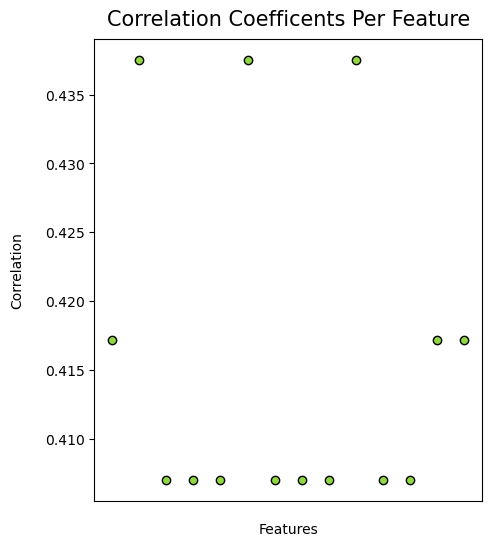

In [35]:
fig,ax = plt.subplots(figsize=(5, 6)) 
ax.scatter(spearman_df["Features"], spearman_df["Correlations"], color="#8FD744FF", edgecolors="black")
ax.set_title("Correlation Coefficents Per Feature", fontsize = 15, pad=10)
ax.set_xlabel("Features", fontsize=10, labelpad=15)
ax.set_ylabel("Correlation", fontsize=10, labelpad=15)

plt.tick_params(bottom=False, labelbottom=False)
plt.show()

In [36]:
# Store spearman features
spearman_rad = spearman_df["Features"].to_list()

In [37]:
# Seperating out the features
rad_spear = rad_train_test_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
rad_spear = rad_spear.loc[:, rad_spear.columns.isin(spearman_rad)]
# Seperating out the target
rad_class = rad_train_test_df[["SURGICAL"]]

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


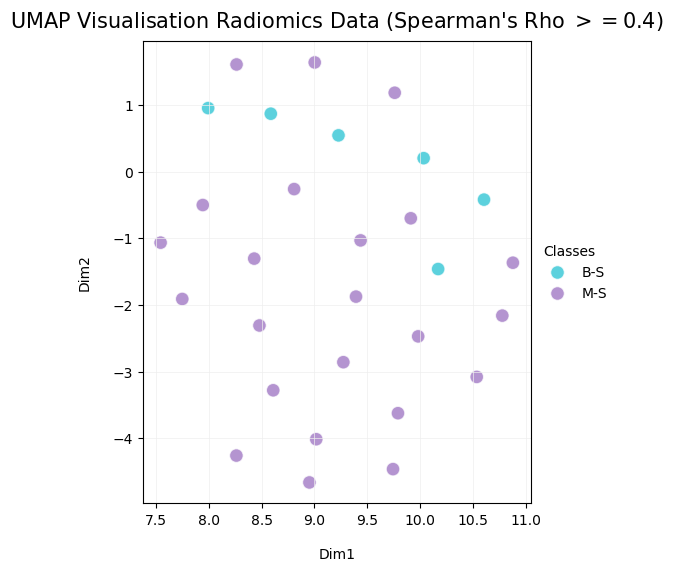

In [38]:
draw_umap_class(n_neighbors=50, min_dist=0.5, title="UMAP Visualisation Radiomics Data (Spearman's Rho $ >= 0.4$)", num_features=rad_spear)

### RNA Tabular Data

In [39]:
# Scale RNA sample counts
rna_scaler = StandardScaler()
rna_train_df = pd.DataFrame(rna_scaler.fit_transform(rna_train), columns=rna_data_filtered.columns)
rna_train_df.insert(0, "SURGICAL", surg_train)

In [40]:
rna_train_df

1,SURGICAL,ENSG00000279928,ENSG00000228037,ENSG00000142611,ENSG00000284616,ENSG00000157911,ENSG00000260972,ENSG00000224340,ENSG00000226374,ENSG00000229280,...,ENSG00000198886,ENSG00000210176,ENSG00000210184,ENSG00000210191,ENSG00000198786,ENSG00000198695,ENSG00000210194,ENSG00000198727,ENSG00000210195,ENSG00000210196
0,M-S,0.391489,2.095373,0.845661,0.0,-0.706518,-0.213201,0.0,-0.273434,0.0,...,0.982061,-0.458831,-0.213201,-0.458831,-0.249747,-0.598463,-0.098433,0.593454,0.0,0.405475
1,M-S,-0.608984,3.877982,-0.323115,0.0,0.969914,-0.213201,0.0,-0.273434,0.0,...,-0.462295,-0.458831,-0.213201,-0.458831,-0.608811,-1.222228,-1.356184,-0.633742,0.0,-0.799880
2,M-S,2.392435,-0.412902,-0.345168,0.0,-0.366051,4.690416,0.0,-0.273434,0.0,...,0.542950,2.179449,-0.213201,-0.458831,2.369211,1.905593,2.165519,0.649293,0.0,1.536534
3,M-S,1.391962,-0.570655,-0.179775,0.0,0.022526,-0.213201,0.0,-0.273434,0.0,...,-0.439767,-0.458831,-0.213201,2.179449,-0.197033,-0.315460,0.153118,-0.379423,0.0,-0.643496
4,M-S,0.391489,-0.144721,2.499588,0.0,0.092840,-0.213201,0.0,1.298813,0.0,...,0.925221,-0.458831,-0.213201,-0.458831,-0.159288,0.478861,-0.098433,0.594507,0.0,0.026723
5,M-S,-0.608984,-0.539104,-1.117001,0.0,-1.117300,-0.213201,0.0,4.443309,0.0,...,0.503722,-0.458831,-0.213201,2.179449,-0.517806,-0.230226,-1.607734,0.483332,0.0,1.357289
6,M-S,1.892199,-0.428677,0.139985,0.0,0.126147,-0.213201,0.0,-0.273434,0.0,...,-0.830967,2.179449,-0.213201,-0.458831,-0.740485,-0.584550,-0.601533,-0.532274,0.0,-0.567642
7,M-S,1.892199,-0.334025,-1.183158,0.0,-0.247627,-0.213201,0.0,-0.273434,0.0,...,-0.803359,2.179449,4.690416,2.179449,0.426300,0.350044,0.404668,-0.600500,0.0,0.462625
8,B-S,-0.608984,-0.255148,-0.764163,0.0,0.118745,-0.213201,0.0,-0.273434,0.0,...,-0.076327,-0.458831,-0.213201,-0.458831,-0.470768,1.787090,1.913969,-0.312919,0.0,-0.664278
9,M-S,-0.608984,0.312763,0.128958,0.0,-1.628001,-0.213201,0.0,-0.273434,0.0,...,-0.540527,-0.458831,-0.213201,-0.458831,-0.622723,-0.222019,-0.349983,-0.449639,0.0,-0.869500


In [41]:
# Scale RNA sample counts
rna_test_df = pd.DataFrame(rna_scaler.transform(rna_test), columns=rna_data_filtered.columns)
rna_test_df.insert(0, "SURGICAL", surg_test)

In [42]:
rna_test_df

1,SURGICAL,ENSG00000279928,ENSG00000228037,ENSG00000142611,ENSG00000284616,ENSG00000157911,ENSG00000260972,ENSG00000224340,ENSG00000226374,ENSG00000229280,...,ENSG00000198886,ENSG00000210176,ENSG00000210184,ENSG00000210191,ENSG00000198786,ENSG00000198695,ENSG00000210194,ENSG00000198727,ENSG00000210195,ENSG00000210196
0,M-S,-0.608984,-0.239373,-0.477482,0.0,0.907002,-0.213201,0.0,-0.273434,0.0,...,-0.230147,-0.458831,-0.213201,2.179449,-0.194027,0.074502,0.153118,-0.438142,0.0,-0.039260
1,B-S,-0.608984,-0.570655,-0.003356,0.0,0.714564,-0.213201,0.0,-0.273434,0.0,...,-0.660209,-0.458831,-0.213201,-0.458831,-0.811365,-0.757916,-0.098433,-0.266905,0.0,-0.721948
2,B-S,-0.608984,-0.192047,-0.477482,0.0,-0.958168,-0.213201,0.0,-0.273434,0.0,...,0.059708,-0.458831,-0.213201,4.817730,1.774239,3.224488,4.177921,0.184761,0.0,1.058548
3,B-S,-0.608984,-0.412902,-0.102591,0.0,-0.625102,-0.213201,0.0,-0.273434,0.0,...,-0.843831,-0.458831,-0.213201,-0.458831,0.512576,1.189747,0.907768,-0.571954,0.0,-0.781696
4,M-S,-0.608984,-0.113171,-1.194184,0.0,-0.773132,-0.213201,0.0,-0.273434,0.0,...,1.925039,-0.458831,-0.213201,-0.458831,0.629136,1.063695,1.159318,0.332271,0.0,0.205968
5,M-S,-0.608984,-0.349800,-0.565691,0.0,-1.324541,-0.213201,0.0,-0.273434,0.0,...,2.166943,-0.458831,-0.213201,-0.458831,0.423011,0.902619,2.165519,1.465487,0.0,0.188822


In [43]:
rna_train_test_df = pd.concat([rna_train_df, rna_test_df], ignore_index=True)

In [44]:
rna_train_test_df

1,SURGICAL,ENSG00000279928,ENSG00000228037,ENSG00000142611,ENSG00000284616,ENSG00000157911,ENSG00000260972,ENSG00000224340,ENSG00000226374,ENSG00000229280,...,ENSG00000198886,ENSG00000210176,ENSG00000210184,ENSG00000210191,ENSG00000198786,ENSG00000198695,ENSG00000210194,ENSG00000198727,ENSG00000210195,ENSG00000210196
0,M-S,0.391489,2.095373,0.845661,0.0,-0.706518,-0.213201,0.0,-0.273434,0.0,...,0.982061,-0.458831,-0.213201,-0.458831,-0.249747,-0.598463,-0.098433,0.593454,0.0,0.405475
1,M-S,-0.608984,3.877982,-0.323115,0.0,0.969914,-0.213201,0.0,-0.273434,0.0,...,-0.462295,-0.458831,-0.213201,-0.458831,-0.608811,-1.222228,-1.356184,-0.633742,0.0,-0.799880
2,M-S,2.392435,-0.412902,-0.345168,0.0,-0.366051,4.690416,0.0,-0.273434,0.0,...,0.542950,2.179449,-0.213201,-0.458831,2.369211,1.905593,2.165519,0.649293,0.0,1.536534
3,M-S,1.391962,-0.570655,-0.179775,0.0,0.022526,-0.213201,0.0,-0.273434,0.0,...,-0.439767,-0.458831,-0.213201,2.179449,-0.197033,-0.315460,0.153118,-0.379423,0.0,-0.643496
4,M-S,0.391489,-0.144721,2.499588,0.0,0.092840,-0.213201,0.0,1.298813,0.0,...,0.925221,-0.458831,-0.213201,-0.458831,-0.159288,0.478861,-0.098433,0.594507,0.0,0.026723
5,M-S,-0.608984,-0.539104,-1.117001,0.0,-1.117300,-0.213201,0.0,4.443309,0.0,...,0.503722,-0.458831,-0.213201,2.179449,-0.517806,-0.230226,-1.607734,0.483332,0.0,1.357289
6,M-S,1.892199,-0.428677,0.139985,0.0,0.126147,-0.213201,0.0,-0.273434,0.0,...,-0.830967,2.179449,-0.213201,-0.458831,-0.740485,-0.584550,-0.601533,-0.532274,0.0,-0.567642
7,M-S,1.892199,-0.334025,-1.183158,0.0,-0.247627,-0.213201,0.0,-0.273434,0.0,...,-0.803359,2.179449,4.690416,2.179449,0.426300,0.350044,0.404668,-0.600500,0.0,0.462625
8,B-S,-0.608984,-0.255148,-0.764163,0.0,0.118745,-0.213201,0.0,-0.273434,0.0,...,-0.076327,-0.458831,-0.213201,-0.458831,-0.470768,1.787090,1.913969,-0.312919,0.0,-0.664278
9,M-S,-0.608984,0.312763,0.128958,0.0,-1.628001,-0.213201,0.0,-0.273434,0.0,...,-0.540527,-0.458831,-0.213201,-0.458831,-0.622723,-0.222019,-0.349983,-0.449639,0.0,-0.869500


### RNA - Principal Component Analysis (2 Components)

#### All features

In [45]:
# Seperating out the features
rna_all = rna_train_test_df.drop(["SURGICAL"], axis=1)
# Seperating out the target
rna_class = rna_train_test_df[["SURGICAL"]]

In [46]:
def draw_umap_rna_class(n_neighbors=15, min_dist=0.1, n_components=2, metric='euclidean', title='', num_features=""):

    rna_reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        metric=metric
    )

    rna_umap_results = rna_reducer.fit_transform(num_features)

    fig, ax = plt.subplots(figsize=(5, 6))
    plt.rcParams['axes.spines.left'] = True
    plt.rcParams['axes.spines.right'] = True
    plt.rcParams['axes.spines.top'] = True
    plt.rcParams['axes.spines.bottom'] = True

    targets = ["B-S", "M-S"]
    colours = ["#17BECF", "#9467BD"]

    sns.scatterplot(x=rna_umap_results[:,0], y=rna_umap_results[:,1], hue=rna_class.SURGICAL, palette=colours, hue_order=targets, alpha=0.7, s=95)

    ax.grid(which="major", color="#EEEEEE", linewidth=0.5)
    ax.set_xlabel("Dim1", fontsize=10, labelpad=15)
    ax.set_ylabel("Dim2", fontsize=10, labelpad=15)
    ax.set_title(title, fontsize = 15, pad=10)
    plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
    plt.show()

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


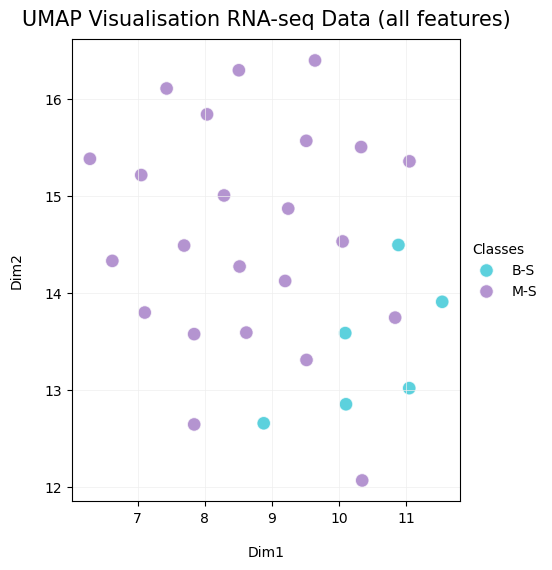

In [47]:
draw_umap_rna_class(n_neighbors=50, min_dist=0.5, title="UMAP Visualisation RNA-seq Data (all features)", num_features=rna_all)

#### Run LDA on the Original Dataset to Select Features

In [48]:
# Divide the dataset into features (X) and target variable (y)
X = rna_train_test_df.drop(["SURGICAL"], axis=1)
y = rna_train_test_df[["SURGICAL"]]

# Fit the LDA model
model = LinearDiscriminantAnalysis()
model.fit(X, y)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LinearDiscriminantAnalysis()

In [49]:
# Print coefficient table
coef_table = pd.DataFrame(list(X.columns)).copy()
coef_table.insert(len(coef_table.columns), "Coefficients", model.coef_.transpose())
coef_table

,0,Coefficients
0,ENSG00000279928,-1.704994e-04
1,ENSG00000228037,2.136670e-05
2,ENSG00000142611,3.066765e-04
3,ENSG00000284616,-6.344333e-17
4,ENSG00000157911,8.422049e-05
...,...,...
63182,ENSG00000198695,-9.792529e-05
63183,ENSG00000210194,-2.199868e-04
63184,ENSG00000198727,4.729384e-05
63185,ENSG00000210195,0.000000e+00


In [50]:
# Add absoloute coefficients column
coef_table["Absolute Coefficients"] = coef_table["Coefficients"].abs()
coef_table

,0,Coefficients,Absolute Coefficients
0,ENSG00000279928,-1.704994e-04,1.704994e-04
1,ENSG00000228037,2.136670e-05,2.136670e-05
2,ENSG00000142611,3.066765e-04,3.066765e-04
3,ENSG00000284616,-6.344333e-17,6.344333e-17
4,ENSG00000157911,8.422049e-05,8.422049e-05
...,...,...,...
63182,ENSG00000198695,-9.792529e-05,9.792529e-05
63183,ENSG00000210194,-2.199868e-04,2.199868e-04
63184,ENSG00000198727,4.729384e-05,4.729384e-05
63185,ENSG00000210195,0.000000e+00,0.000000e+00


In [51]:
# Sort absolute coefficients 
coef_table = coef_table.sort_values(by="Absolute Coefficients", ascending=False)
coef_table

,0,Coefficients,Absolute Coefficients
37369,ENSG00000232853,-0.002529,0.002529
46739,ENSG00000201084,-0.002529,0.002529
41418,ENSG00000272921,-0.002034,0.002034
25336,ENSG00000286137,-0.002029,0.002029
54165,ENSG00000264421,-0.002029,0.002029
...,...,...,...
6656,ENSG00000270891,0.000000,0.000000
12421,ENSG00000288793,0.000000,0.000000
26321,ENSG00000235892,0.000000,0.000000
6652,ENSG00000227259,0.000000,0.000000


In [52]:
# Store top 1000 features
top_1000_rna = coef_table[0].head(1000).to_list()

In [53]:
# Seperating out the features
rna_1000 = rna_train_test_df.drop(["SURGICAL"], axis=1)
# Only keep the top 1000 features
rna_1000 = rna_1000.loc[:, rna_1000.columns.isin(top_1000_rna)]
# Seperating out the target
rna_class = rna_train_test_df[["SURGICAL"]]

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


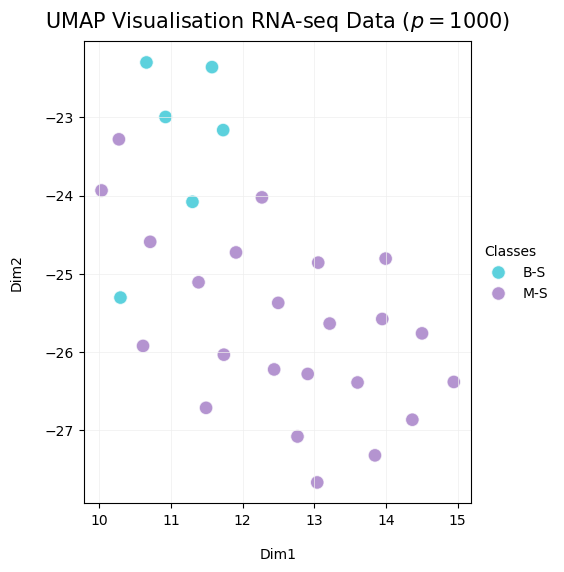

In [54]:
draw_umap_rna_class(n_neighbors=50, min_dist=0.5, title="UMAP Visualisation RNA-seq Data ($p=1000$)", num_features=rna_1000)

#### Spearman Rho Correlation Coefficient

In [55]:
# Seperating out the features
rna_all = rna_train_test_df.drop(["SURGICAL"], axis=1)
# Seperating out the target
rna_class_cat = pd.Categorical(rna_train_test_df["SURGICAL"].astype("category")).codes

In [60]:
rna_thresholds, rna_threshold_counts = spearman_thresh_function(rna_all, rna_class_cat, thresholds)

/tmp/ipykernel_66783/673404981.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(features[column], target)


In [61]:
threshold_df = pd.DataFrame(
    {
        "Threshold": map(str, rna_thresholds),
        "Feature Count": rna_threshold_counts
    }
)

threshold_df

,Threshold,Feature Count
0,0,30102
1,0.1,21120
2,0.2,12900
3,0.3,6784
4,0.4,3274
5,0.5,1088
6,0.6,127
7,0.7,1
8,0.8,0
9,0.9,0


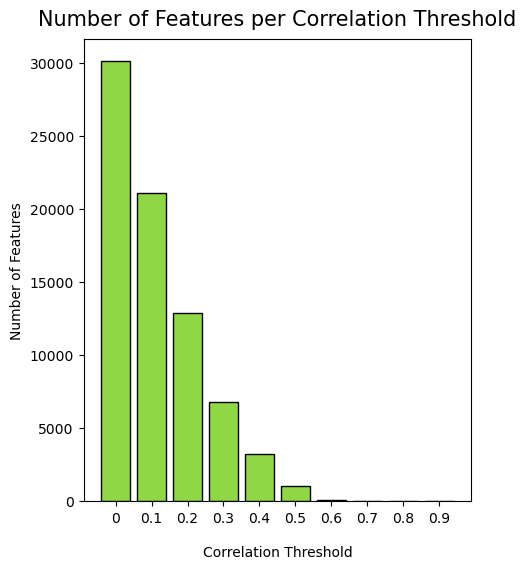

In [62]:
fig,ax = plt.subplots(figsize=(5, 6)) 
ax.bar(threshold_df["Threshold"], threshold_df["Feature Count"], color="#8FD744FF", edgecolor="black")
ax.set_title("Number of Features per Correlation Threshold", fontsize = 15, pad=10)
ax.set_xlabel("Correlation Threshold", fontsize=10, labelpad=15)
ax.set_ylabel("Number of Features", fontsize=10)
plt.show()

In [56]:
rna_feature_names, rna_feature_correlations = spearman_df_function(rna_all, rna_class_cat, 0.65)

/tmp/ipykernel_66918/2827494689.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(features[column], target)


In [57]:
spearman_df = pd.DataFrame(
    {
        "Features": rna_feature_names,
        "Correlations": rna_feature_correlations
    }
)

spearman_df

,Features,Correlations
0,ENSG00000197622,0.671514
1,ENSG00000085999,0.666674
2,ENSG00000138074,0.661340
3,ENSG00000281357,0.704035
4,ENSG00000173334,0.651166
5,ENSG00000104312,0.661421
6,ENSG00000137547,0.661340
7,ENSG00000135069,0.651166
8,ENSG00000175592,0.671514
9,ENSG00000134333,0.651166


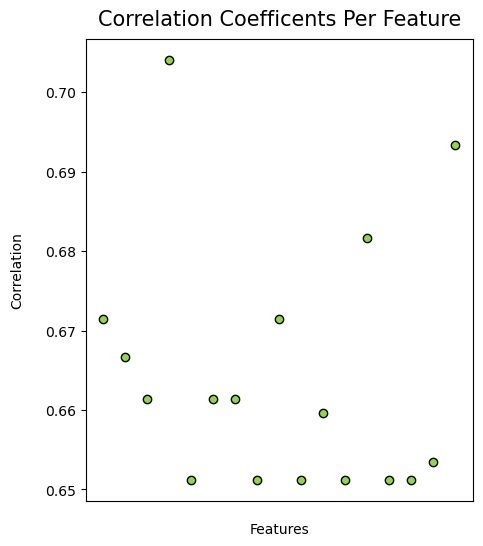

In [58]:
fig,ax = plt.subplots(figsize=(5, 6)) 
ax.scatter(spearman_df["Features"], spearman_df["Correlations"], color="#8FD744FF", edgecolors="black")
ax.set_title("Correlation Coefficents Per Feature", fontsize = 15, pad=10)
ax.set_xlabel("Features", fontsize=10, labelpad=15)
ax.set_ylabel("Correlation", fontsize=10, labelpad=15)

plt.tick_params(bottom=False, labelbottom=False)
plt.show()

In [59]:
# Store spearman features
spearman_rna = spearman_df["Features"].to_list()

In [60]:
# Seperating out the features
rna_spear = rna_train_test_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
rna_spear = rna_spear.loc[:, rna_spear.columns.isin(spearman_rna)]
# Seperating out the target
rna_class = rna_train_test_df[["SURGICAL"]]

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


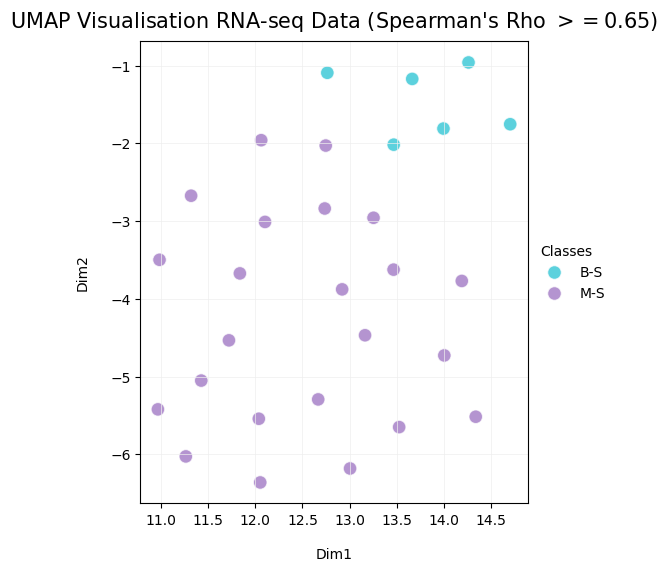

In [61]:
draw_umap_rna_class(n_neighbors=50, min_dist=0.5, title="UMAP Visualisation RNA-seq Data (Spearman's Rho $ >= 0.65$)", num_features=rna_spear)